In [100]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
fashion_mnist=fashion_mnist.load_data()
(X_train, y_train), (X_test, y_test) = fashion_mnist
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [102]:
# normalize pixels value
X_train=X_train/255.0
X_test=X_test/255.0

# reshape value
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)


In [103]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [104]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,BatchNormalization, Dropout

# define layers
model=Sequential()
# first layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
# second layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
# third layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10,activation='softmax'))
model.summary()

c:\Users\Gaurav\OneDrive\Desktop\Ai-Ml learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,194 (239.04 KB)

 Trainable params: 60,874 (237.79 KB)

 Non-trainable params: 320 (1.25 KB)

In [105]:
#Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=4, # how many epochs to wait before stopping
    restore_best_weights=True,
    verbose=1,
)


In [106]:
#compile model
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [107]:
# train model
model_history=model.fit(X_train,y_train,validation_split=0.2,batch_size=32,epochs=20,callbacks=[early_stopping])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8015 - loss: 0.5656 - val_accuracy: 0.8569 - val_loss: 0.3884
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8599 - loss: 0.3933 - val_accuracy: 0.8557 - val_loss: 0.3934
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8770 - loss: 0.3469 - val_accuracy: 0.8759 - val_loss: 0.3392
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8868 - loss: 0.3116 - val_accuracy: 0.8837 - val_loss: 0.3136
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8970 - loss: 0.2833 - val_accuracy: 0.8915 - val_loss: 0.2930
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9039 - loss: 0.2624 - val_accuracy: 0.8842 - val_loss: 0.3095
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9105 - loss: 0.2470 - val_accuracy: 0.8905 - val_loss: 0.3034
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9153 - lo

In [108]:
(test_loss,test_accuracy)=model.evaluate(X_test,y_test)
print('Test loss: {}'.format(test_loss))
print('Test accuracy: {}'.format(test_accuracy))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8854 - loss: 0.3097
Test loss: 0.3097335994243622
Test accuracy: 0.8853999972343445


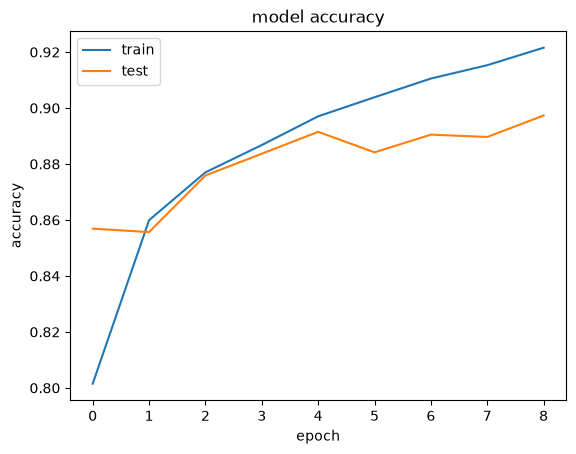

In [109]:
# summarize history from model
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='best')
plt.title('model accuracy')
plt.show()

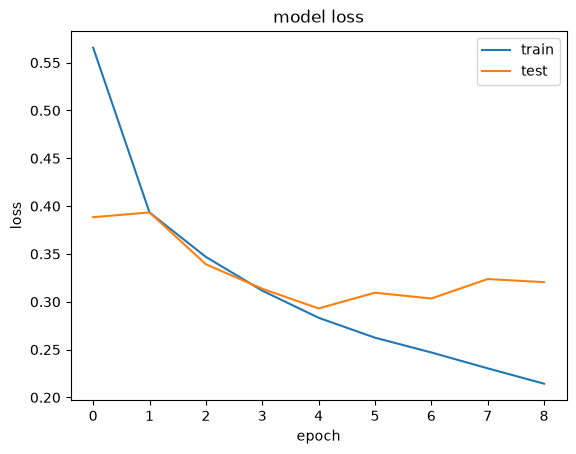

In [110]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('model loss')
plt.legend(['train','test'],loc='best')
plt.show()

In [111]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
y_pred = model.predict(X_test)
predicted_digit = np.argmax(y_pred, axis=1)

actual_digit = class_names[np.argmax(y_test[14])]

print("Predicted:", class_names[predicted_digit[14]])
print("Actual:", actual_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted: Coat
Actual: Coat


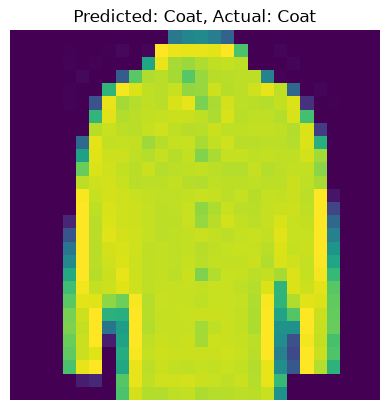

In [112]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(X_test[14].reshape(28, 28))
plt.title(
    f"Predicted: {class_names[np.argmax(y_pred[14])]}, Actual: {class_names[np.argmax(y_test[14])]}"
)
plt.axis("off")
plt.show()

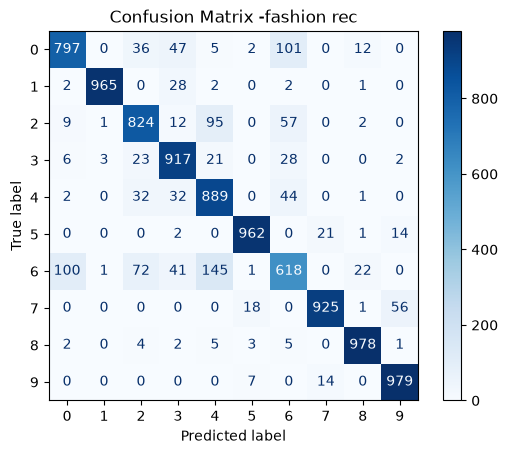

In [113]:
from sklearn.metrics import ConfusionMatrixDisplay

# Convert y_test from one-hot encoding to single integer labels
y_test_labels = np.argmax(y_test, axis=1)

# Convert y_pred probabilities to single integer labels
y_pred_labels = np.argmax(y_pred, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels,
                                        cmap="Blues"
)
plt.title("Confusion Matrix -fashion rec")
plt.show()

In [114]:
from sklearn.metrics import classification_report

# Convert y_test from one-hot encoding to single integer labels
y_test_labels = np.argmax(y_test, axis=1)

# Convert y_pred probabilities to single integer labels
y_pred_labels = np.argmax(y_pred, axis=1)
print(classification_report(y_pred_labels,y_test_labels))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       918
           1       0.96      0.99      0.98       970
           2       0.82      0.83      0.83       991
           3       0.92      0.85      0.88      1081
           4       0.89      0.77      0.82      1162
           5       0.96      0.97      0.97       993
           6       0.62      0.72      0.67       855
           7       0.93      0.96      0.94       960
           8       0.98      0.96      0.97      1018
           9       0.98      0.93      0.95      1052

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.89     10000

